📈 Sprint 3 – Advanced Statistics & Feature Engineering

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

dff = pd.read_csv('Flight_Delays_50K_cleaned.csv', parse_dates=['FLIGHT_DATE'])
for c in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'CANCELLATION_REASON', 'TAIL_NUMBER',
          'ORIGIN_CODE_FORMAT', 'DEST_CODE_FORMAT']:
    dff[c] = dff[c].astype('category')

print(dff.shape)

(50000, 35)


Step 1: Statistical Analysis

In [2]:
desc = dff[['ARRIVAL_DELAY', 'DEPARTURE_DELAY', 'DISTANCE']].agg(
    ['count', 'mean', 'median', 'std', 'skew', 'min', 'max']).T.round(2)
desc

,count,mean,median,std,skew,min,max
ARRIVAL_DELAY,49085.0,4.00,-5.0,37.75,6.39,-70.0,1574.0
DEPARTURE_DELAY,49234.0,9.09,-2.0,35.46,7.27,-55.0,1515.0
DISTANCE,50000.0,824.20,646.0,611.89,1.45,31.0,4983.0


**Observation:** For both delay variables the mean (4.00 and 9.09 min) is far above the median (-5.0 and -2.0 min), and skewness is above 6. DISTANCE is moderately right-skewed (1.45).

**Interpretation:** A small number of extreme delays (up to about 1,500 minutes) pull the mean upward, so the median describes the typical flight better. The standard deviation (about 38 and 35 min) is far larger than the mean, showing very high variability.

**Business insight:** "Average delay" overstates the typical passenger experience. Most flights arrive early; the problem is a tail of severe delays.

In [3]:
num_cols = ['DEPARTURE_DELAY', 'ARRIVAL_DELAY', 'TAXI_OUT', 'TAXI_IN', 'AIR_TIME',
            'SCHEDULED_TIME', 'DISTANCE', 'AIR_SYSTEM_DELAY', 'AIRLINE_DELAY',
            'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

cov_matrix = dff[num_cols].cov().round(2)
cov_matrix

,DEPARTURE_DELAY,ARRIVAL_DELAY,TAXI_OUT,TAXI_IN,AIR_TIME,SCHEDULED_TIME,DISTANCE,AIR_SYSTEM_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
DEPARTURE_DELAY,1257.75,1251.86,21.07,0.21,64.33,74.89,536.60,138.06,473.76,455.90,82.76
ARRIVAL_DELAY,1251.86,1425.44,78.56,22.65,-22.43,-94.80,-647.39,207.08,485.34,466.55,90.88
TAXI_OUT,21.07,78.56,77.54,-0.06,57.21,77.72,409.40,37.07,8.78,5.24,6.51
TAXI_IN,0.21,22.65,-0.06,31.49,34.70,43.50,269.35,13.98,0.01,0.97,0.34
AIR_TIME,64.33,-22.43,57.21,34.70,5264.86,5443.54,43833.78,24.07,34.72,-20.62,-0.66
SCHEDULED_TIME,74.89,-94.80,77.72,43.50,5443.54,5714.96,45535.57,7.49,34.12,-21.57,-1.42
DISTANCE,536.60,-647.39,409.40,269.35,43833.78,45535.57,374407.33,8.71,263.72,-158.82,-23.16
AIR_SYSTEM_DELAY,138.06,207.08,37.07,13.98,24.07,7.49,8.71,156.98,10.01,14.91,5.92
AIRLINE_DELAY,473.76,485.34,8.78,0.01,34.72,34.12,263.72,10.01,421.58,23.63,-0.32
LATE_AIRCRAFT_DELAY,455.90,466.55,5.24,0.97,-20.62,-21.57,-158.82,14.91,23.63,386.48,6.52


In [4]:
corr_matrix = dff[num_cols].corr().round(3)

pairs = [('DEPARTURE_DELAY', 'ARRIVAL_DELAY'), ('AIR_TIME', 'DISTANCE'),
         ('ARRIVAL_DELAY', 'LATE_AIRCRAFT_DELAY'), ('ARRIVAL_DELAY', 'WEATHER_DELAY')]

for a, b in pairs:
    print(f"{a} vs {b}: covariance = {cov_matrix.loc[a, b]:.1f}, correlation = {corr_matrix.loc[a, b]:.3f}")
    

DEPARTURE_DELAY vs ARRIVAL_DELAY: covariance = 1251.9, correlation = 0.941
AIR_TIME vs DISTANCE: covariance = 43833.8, correlation = 0.985
ARRIVAL_DELAY vs LATE_AIRCRAFT_DELAY: covariance = 466.6, correlation = 0.623
ARRIVAL_DELAY vs WEATHER_DELAY: covariance = 90.9, correlation = 0.278


In [5]:
for col in ['ARRIVAL_DELAY', 'DEPARTURE_DELAY', 'DISTANCE']:
    sample = dff[col].dropna().sample(min(5000, dff[col].dropna().shape[0]), random_state=42)
    stat, p_value = stats.shapiro(sample)
    print(f"{col}: Shapiro-Wilk stat={stat:.4f}, p-value={p_value:.2e}")

ARRIVAL_DELAY: Shapiro-Wilk stat=0.5874, p-value=4.75e-76
DEPARTURE_DELAY: Shapiro-Wilk stat=0.4456, p-value=2.14e-82
DISTANCE: Shapiro-Wilk stat=0.8780, p-value=1.29e-52


In [6]:
print(corr_matrix.loc['ARRIVAL_DELAY', ['AIR_TIME', 'SCHEDULED_TIME', 'DISTANCE']])
print(corr_matrix.loc['DEPARTURE_DELAY', ['AIR_TIME', 'SCHEDULED_TIME', 'DISTANCE']])

AIR_TIME         -0.008
SCHEDULED_TIME   -0.033
DISTANCE         -0.028
Name: ARRIVAL_DELAY, dtype: float64
AIR_TIME          0.025
SCHEDULED_TIME    0.028
DISTANCE          0.025
Name: DEPARTURE_DELAY, dtype: float64


### Step 1 Interpretation

**Covariance vs correlation:** All key pairs have positive covariance, so they move together. But covariance depends on scale: AIR_TIME vs DISTANCE has a covariance about 35 times larger than DEPARTURE_DELAY vs ARRIVAL_DELAY (43,833.8 vs 1,251.9), yet its correlation is only slightly higher (0.985 vs 0.941), because DISTANCE has a variance of 374,407. Relationships should therefore be ranked by correlation, with covariance used only for direction.

**Delay relationships:** Departure delay and arrival delay are almost perfectly linked (r = 0.941), so delays are largely created before takeoff. Arrival delay relates to late-aircraft delay (r = 0.623) far more than to weather delay (r = 0.278).

**Sign check (arrival delay vs flight length):** Arrival delay has small negative Pearson correlations with AIR_TIME (-0.008), SCHEDULED_TIME (-0.033) and DISTANCE (-0.028), while departure delay has small positive ones (about 0.025). Spearman agrees on the signs (Sprint 2 found rho = -0.07 for distance). All values are tiny, so the effect is not operationally important. It is consistent with longer flights having more time in the air to recover lost minutes.

**Normality:** Shapiro-Wilk rejects normality for ARRIVAL_DELAY (W = 0.587), DEPARTURE_DELAY (W = 0.446) and DISTANCE (W = 0.878), all with p < 0.001. **Consequence:** mean comparisons in Step 2 are paired with non-parametric tests (Mann-Whitney U, Kruskal-Wallis), and large sample sizes support the Central Limit Theorem for the parametric versions.

Step 2: Hypothesis Testing

In [7]:
sample = dff['ARRIVAL_DELAY'].dropna()

t_stat, p_value = stats.ttest_1samp(sample, popmean=0)
print(f"T-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.2e}")
print(f"Sample mean: {sample.mean():.3f}, n = {len(sample):,}")

T-statistic: 23.469
p-value: 3.91e-121
Sample mean: 3.999, n = 49,085


**Test 1: One-sample T-test (mean arrival delay vs 0)**
- **Null Hypothesis:** the true mean arrival delay is 0 minutes.
- **Alternate Hypothesis:** the true mean arrival delay is not 0 minutes.
- **Test Statistic:** t = 23.469 (n = 49,085, sample mean = 4.00 min).
- **p-value:** 3.91e-121.
- **Decision:** reject H0 at alpha = 0.05.
- **Business Interpretation:** flights are late on average, but the effect is small in practical terms (Cohen's d about 0.11) and the median flight arrives 5 minutes early. The significance comes from the large sample, which illustrates statistical vs practical significance.

In [8]:
nk = dff[dff['AIRLINE'] == 'NK']['ARRIVAL_DELAY'].dropna()
others = dff[dff['AIRLINE'] != 'NK']['ARRIVAL_DELAY'].dropna()

t_stat, p_value = stats.ttest_ind(nk, others, equal_var=False)
u_stat, p_value_mw = stats.mannwhitneyu(nk, others, alternative='two-sided')

print(f"Welch's T-test: t={t_stat:.3f}, p={p_value:.2e}")
print(f"Mann-Whitney U (non-parametric): U={u_stat:.1f}, p={p_value_mw:.2e}")
print(f"NK mean: {nk.mean():.2f}, n={len(nk):,} | Others mean: {others.mean():.2f}, n={len(others):,}")

Welch's T-test: t=7.782, p=1.76e-14
Mann-Whitney U (non-parametric): U=28476099.0, p=7.47e-30
NK mean: 14.51, n=977 | Others mean: 3.79, n=48,108


**Test 2: Welch's T-test and Mann-Whitney U (NK vs all other airlines)**
- **Null Hypothesis:** NK's arrival delay is the same as that of all other airlines.
- **Alternate Hypothesis:** NK's arrival delay differs from the others.
- **Test Statistic:** Welch t = 7.782; Mann-Whitney U = 28,476,099.
- **p-value:** 1.76e-14 (Welch); 7.47e-30 (Mann-Whitney).
- **Decision:** reject H0; both tests agree, so the result is robust to non-normality. Welch was used because NK's variance differs from the others.
- **Business Interpretation:** NK averages 14.51 min against 3.79 min for the rest (NK median 2.0 vs -5.0 min), so NK is worse for the typical flight, not only in the tail. NK has only 977 valid flights.

In [9]:
top_airlines = dff['AIRLINE'].value_counts().head(6).index
groups = [dff[dff['AIRLINE'] == a]['ARRIVAL_DELAY'].dropna() for a in top_airlines]

f_stat, p_value = stats.f_oneway(*groups)
h_stat, p_value_kw = stats.kruskal(*groups)

print(f"Top 6 airlines: {list(top_airlines)}")
print(f"ANOVA: F={f_stat:.3f}, p={p_value:.2e}")
print(f"Kruskal-Wallis: H={h_stat:.3f}, p={p_value_kw:.2e}")

Top 6 airlines: ['WN', 'DL', 'AA', 'OO', 'EV', 'UA']
ANOVA: F=21.591, p=1.19e-21
Kruskal-Wallis: H=414.494, p=2.23e-87


**Test 3: One-way ANOVA and Kruskal-Wallis (WN, DL, AA, OO, EV, UA)**
- **Null Hypothesis:** all six airlines have the same mean arrival delay.
- **Alternate Hypothesis:** at least one airline's mean differs.
- **Test Statistic:** ANOVA F = 21.591; Kruskal-Wallis H = 414.494.
- **p-value:** 1.19e-21 (ANOVA); 2.23e-87 (Kruskal-Wallis).
- **Decision:** reject H0; both tests agree.
- **Business Interpretation:** punctuality differs among the largest carriers (means: DL 0.26, AA 2.25, UA 4.34, WN 4.39, OO 5.10, EV 6.51 min). ANOVA shows a difference exists but not which pairs differ (a Tukey post-hoc test would).

In [10]:
sub = dff[(dff['CANCELLED'] == 1) &
          (dff['AIRLINE'].isin(['AA', 'EV', 'MQ', 'OO', 'UA', 'WN'])) &
          (dff['CANCELLATION_REASON'].isin(['A', 'B', 'C']))].copy()   # reason D has only 1 flight
sub['AIRLINE'] = sub['AIRLINE'].astype(str)
sub['CANCELLATION_REASON'] = sub['CANCELLATION_REASON'].astype(str)

contingency = pd.crosstab(sub['AIRLINE'], sub['CANCELLATION_REASON'])
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square: {chi2:.3f}, dof={dof}, p-value={p_value:.2e}")
print(f"Smallest expected count: {expected.min():.1f}")
n = contingency.values.sum()
print(f"Cramer's V: {(chi2 / (n * (min(contingency.shape) - 1))) ** 0.5:.3f}")

CANCELLATION_REASON   A   B   C
AIRLINE                        
AA                   29  70   5
EV                   39  57  54
MQ                   23  70  37
OO                   21  63  11
UA                   26  28   5
WN                   48  67  12

Chi-square: 83.145, dof=10, p-value=1.21e-13
Smallest expected count: 11.0
Cramer's V: 0.250


**Test 4: Chi-square test of independence (airline vs cancellation reason)**
- **Null Hypothesis:** cancellation reason is independent of airline.
- **Alternate Hypothesis:** cancellation reason depends on airline.
- **Test Statistic:** chi-square = 83.14, dof = 10. Reason D (1 flight) is excluded because its expected counts would break the chi-square assumption; all remaining expected counts are at least 11.
- **p-value:** 1.21e-13.
- **Decision:** reject H0.
- **Business Interpretation:** cancellation causes differ by carrier (Cramer's V about 0.25, a moderate effect). National Air System cancellations are 36% of EV's and 28% of MQ's, versus 5-12% for AA, OO, UA and WN. Reasons: A = Airline, B = Weather, C = National Air System.

Step 3: Confidence Interval Analysis

In [11]:
def mean_ci(series, confidence=0.95):
    x = series.dropna()
    m = x.mean()
    se = stats.sem(x)
    lo, hi = stats.t.interval(confidence, len(x) - 1, loc=m, scale=se)
    return len(x), m, lo, hi

for col in ['ARRIVAL_DELAY', 'DEPARTURE_DELAY', 'DISTANCE']:
    n, m, lo, hi = mean_ci(dff[col])
    print(f"{col}: mean={m:.2f}, 95% CI=({lo:.2f}, {hi:.2f}), n={n:,}")

n, m, lo, hi = mean_ci(dff['ARRIVAL_DELAY'], 0.99)
print(f"ARRIVAL_DELAY 99% CI: ({lo:.2f}, {hi:.2f})")

ARRIVAL_DELAY: mean=4.00, 95% CI=(3.67, 4.33), n=49,085
DEPARTURE_DELAY: mean=9.09, 95% CI=(8.77, 9.40), n=49,234
DISTANCE: mean=824.20, 95% CI=(818.84, 829.57), n=50,000
ARRIVAL_DELAY 99% CI: (3.56, 4.44)


In [12]:
rows = []
for airline, g in dff.groupby('AIRLINE', observed=True):
    n, m, lo, hi = mean_ci(g['ARRIVAL_DELAY'])
    rows.append((airline, n, round(m, 2), round(lo, 2), round(hi, 2), round(hi - lo, 2)))

ci_df = pd.DataFrame(rows, columns=['AIRLINE', 'n', 'mean', 'CI_low', 'CI_high', 'width']).sort_values('mean')
ci_df

,AIRLINE,n,mean,CI_low,CI_high,width
1,AS,1511,-1.17,-2.52,0.18,2.70
3,DL,7442,0.26,-0.55,1.07,1.61
6,HA,674,1.08,-0.20,2.37,2.58
0,AA,6085,2.25,1.17,3.34,2.17
11,US,1662,2.91,1.28,4.54,3.26
10,UA,4277,4.34,3.04,5.65,2.61
13,WN,10796,4.39,3.77,5.00,1.23
9,OO,4884,5.10,4.03,6.17,2.14
2,B6,2274,5.86,4.21,7.52,3.31
7,MQ,2423,6.50,4.93,8.08,3.15


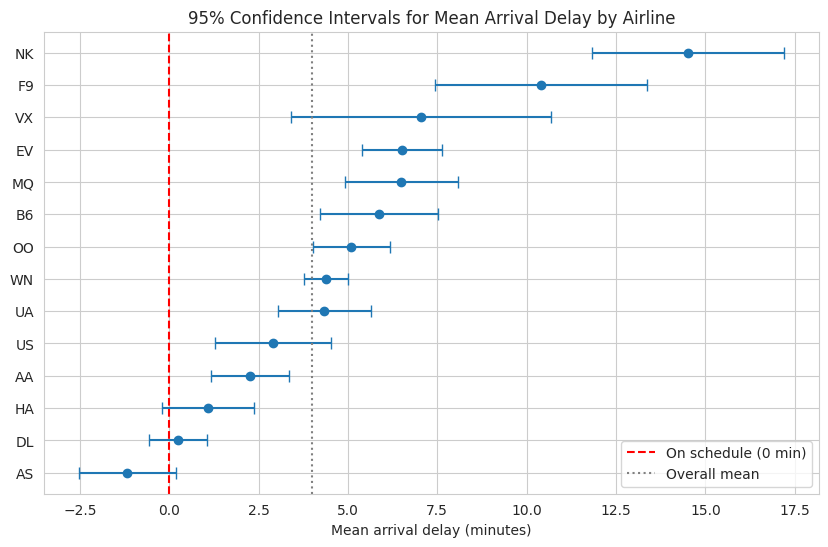

In [13]:
plt.figure(figsize=(10, 6))
plt.errorbar(ci_df['mean'], range(len(ci_df)),
             xerr=[ci_df['mean'] - ci_df['CI_low'], ci_df['CI_high'] - ci_df['mean']],
             fmt='o', capsize=4)
plt.yticks(range(len(ci_df)), ci_df['AIRLINE'])
plt.axvline(0, color='red', linestyle='--', label='On schedule (0 min)')
plt.axvline(dff['ARRIVAL_DELAY'].mean(), color='gray', linestyle=':', label='Overall mean')
plt.xlabel('Mean arrival delay (minutes)')
plt.title('95% Confidence Intervals for Mean Arrival Delay by Airline')
plt.legend()
plt.show()

In [14]:
rng = np.random.default_rng(42)
x = dff['ARRIVAL_DELAY'].dropna().values
boot = [rng.choice(x, len(x)).mean() for _ in range(2000)]
print(np.percentile(boot, [2.5, 97.5]))

[3.66624325 4.34864877]


### Step 3 Interpretation

We are 95% confident the true mean arrival delay is between 3.67 and 4.33 minutes (departure delay: 8.77 to 9.40; distance: 818.8 to 829.6 miles). Zero lies far outside the arrival-delay interval, which agrees with Test 1. The bootstrap interval (about 3.67 to 4.35) matches the t-based one, so the skewed data does not undermine it.

**By airline:** interval width shrinks as sample size grows (WN is tightest; VX and F9 are widest). NK's interval (11.83 to 17.19) overlaps no other airline, while DL, AS and HA include 0, so their average delay cannot be distinguished from on-time.

**Business insight:** the intervals allow carriers to be ranked with an honest margin of error, and small carriers' results should be treated cautiously.

⚙️ 4. Feature Engineering

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
dff = pd.read_csv('Flight_Delays_50K_cleaned.csv', parse_dates=['FLIGHT_DATE'])
fe = dff.copy()

In [16]:
fe['DELAY_CATEGORY'] = pd.cut(fe['ARRIVAL_DELAY'], [-np.inf, 15, 60, np.inf],
                              labels=['On-time/Minor (<=15)', 'Moderate (16-60)', 'Severe (>60)'])
fe.loc[fe['CANCELLED'] == 1, 'DELAY_CATEGORY'] = np.nan

fe['DISTANCE_CATEGORY'] = pd.cut(fe['DISTANCE'], [0, 500, 1500, np.inf],
                                 labels=['Short (<500)', 'Medium (500-1500)', 'Long (>1500)'])

print(fe['DELAY_CATEGORY'].value_counts(normalize=True).round(3))

DELAY_CATEGORY
On-time/Minor (<=15)    0.821
Moderate (16-60)        0.126
Severe (>60)            0.053
Name: proportion, dtype: float64


In [17]:
hour = fe['SCHEDULED_DEPARTURE'] // 100
fe['PEAK_HOUR'] = hour.between(16, 21).astype(int)

# Busy airport = 9 highest-volume origins. About 8.5% of rows use numeric DOT IDs,
# so the numeric IDs of these 9 airports are mapped to their IATA codes
# (each ID's volume is ~9% of its IATA airport's volume, matching the overall numeric share).
dot_to_iata = {'10397': 'ATL', '13930': 'ORD', '11298': 'DFW', '12892': 'LAX', '11292': 'DEN',
               '14107': 'PHX', '14771': 'SFO', '12266': 'IAH', '12889': 'LAS'}
origin = fe['ORIGIN_AIRPORT'].astype(str).replace(dot_to_iata)
fe['BUSY_AIRPORT'] = origin.isin(dot_to_iata.values()).astype(int)

print(origin[origin.isin(dot_to_iata.values())].value_counts())
print(fe[['PEAK_HOUR', 'BUSY_AIRPORT']].mean().round(3))

ORIGIN_AIRPORT
ATL    3269
ORD    2755
DFW    2208
LAX    1890
DEN    1806
PHX    1414
SFO    1378
IAH    1362
LAS    1231
Name: count, dtype: int64
PEAK_HOUR       0.312
BUSY_AIRPORT    0.346
dtype: float64


In [18]:
ontime = fe.groupby('AIRLINE')['ARRIVAL_DELAY'].apply(lambda s: (s.dropna() <= 15).mean())
cancel = fe.groupby('AIRLINE')['CANCELLED'].mean()
score = (ontime * (1 - cancel) * 100).round(1)

fe['AIRLINE_PERFORMANCE_SCORE'] = fe['AIRLINE'].map(score)
score.sort_values(ascending=False)

AIRLINE
HA    89.1
AS    86.5
DL    86.5
AA    81.8
OO    81.4
US    80.7
WN    80.6
UA    79.2
VX    78.3
EV    78.1
B6    78.0
F9    75.1
MQ    73.8
NK    68.3
dtype: float64

In [19]:
fe['LOW_SCORE_AIRLINE'] = (fe['AIRLINE_PERFORMANCE_SCORE'] < score.median()).astype(int)
points = fe['PEAK_HOUR'] + fe['BUSY_AIRPORT'] + fe['LOW_SCORE_AIRLINE']
fe['DELAY_RISK'] = pd.cut(points, [-1, 0, 1, 3], labels=['Low', 'Medium', 'High'])
fe['IS_DELAYED'] = (fe['ARRIVAL_DELAY'] > 15).astype(float).where(fe['ARRIVAL_DELAY'].notna())

fe['DELAY_RISK'].value_counts()

DELAY_RISK
Medium    21074
Low       15850
High      13076
Name: count, dtype: int64

### Feature Documentation

| Feature | Definition | Business purpose |
|---|---|---|
| DELAY_CATEGORY | Arrival delay: <=15 min On-time/Minor, 16-60 Moderate, >60 Severe; cancelled flights left blank | Turns a skewed number into actionable classes using the standard 15-minute on-time rule |
| DISTANCE_CATEGORY | Short (<500 mi), Medium (500-1500), Long (>1500) | Separates flight types with different delay recovery and cancellation behaviour |
| PEAK_HOUR | 1 if scheduled departure hour is 16-21 | Delays build through the day, so evening departures need separate treatment |
| BUSY_AIRPORT | 1 if origin is one of the 9 highest-volume airports (ATL, ORD, DFW, LAX, DEN, PHX, SFO, IAH, LAS) | Flags congestion-prone hubs |
| AIRLINE_PERFORMANCE_SCORE | On-time rate x (1 - cancellation rate) x 100 per airline | One number to rank carrier reliability |
| DELAY_RISK | Points: PEAK_HOUR + BUSY_AIRPORT + below-median airline score; 0 = Low, 1 = Medium, 2-3 = High | Simple flight-level risk index for scheduling and passenger communication |

🎯 5. Feature Evaluation

                       n  mean_arrival  pct_delayed  cancel_rate
DISTANCE_CATEGORY                                               
Short (<500)       18348         4.840        0.177        0.022
Medium (500-1500)  24827         4.304        0.182        0.014
Long (>1500)        6825         0.671        0.170        0.006 

               n  mean_arrival  pct_delayed  cancel_rate
PEAK_HOUR                                               
0          34387         1.714        0.149        0.014
1          15613         9.066        0.245        0.020 

                  n  mean_arrival  pct_delayed  cancel_rate
BUSY_AIRPORT                                               
0             32687         3.465        0.173        0.016
1             17313         5.008        0.189        0.015 

                n  mean_arrival  pct_delayed  cancel_rate
DELAY_RISK                                               
Low         15850         0.144        0.127        0.011
Medium      21074         4

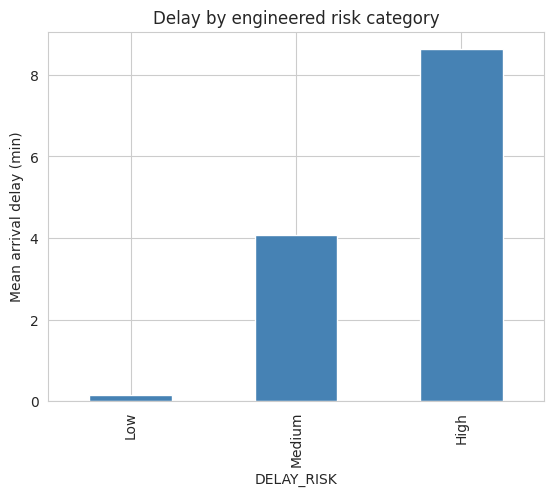

In [20]:
for c in ['DISTANCE_CATEGORY', 'PEAK_HOUR', 'BUSY_AIRPORT', 'DELAY_RISK']:
    print(fe.groupby(c, observed=True).agg(n=('IS_DELAYED', 'size'),
          mean_arrival=('ARRIVAL_DELAY', 'mean'),
          pct_delayed=('IS_DELAYED', 'mean'),
          cancel_rate=('CANCELLED', 'mean')).round(3), '\n')

groups = [g['ARRIVAL_DELAY'].dropna() for _, g in fe.groupby('DELAY_RISK', observed=True)]
print(stats.f_oneway(*groups))
print(stats.kruskal(*groups))

fe.groupby('DELAY_RISK', observed=True)['ARRIVAL_DELAY'].mean().plot(kind='bar', color='steelblue')
plt.ylabel('Mean arrival delay (min)'); plt.title('Delay by engineered risk category'); plt.show()

fe.to_csv('Flight_Delays_50K_featured.csv', index=False)




### Step 5 Interpretation: Feature Evaluation

**Observation:** DELAY_RISK separates flights cleanly. Mean arrival delay rises from 0.14 (Low) to 4.06 (Medium) to 8.62 min (High), and the share of flights delayed over 15 minutes rises from 12.7% to 18.3% to 23.4%. ANOVA (F about 178.6) and Kruskal-Wallis (H about 363.9) are both significant at p < 0.001.

**Interpretation:** the engineered features improve understanding. PEAK_HOUR is the strongest single flag (mean delay 9.07 vs 1.71 min). BUSY_AIRPORT has a smaller effect (5.01 vs 3.47 min). DISTANCE_CATEGORY does not change the share of delayed flights (17-18% in every band) but long flights recover time in the air (mean delay 0.67 vs 4.84 min for short-haul).

**Limitations:** DELAY_RISK is a rule-based descriptive index, not a predictive model, and the airline score is built from the same data it is evaluated on. About 8.5% of airport codes are numeric DOT IDs; only the nine busiest hubs' IDs were mapped.

### Conclusions

- Delays are highly skewed and non-normal, so medians and non-parametric tests give the more reliable picture.
- Departure, late-aircraft and airline-controlled delay explain arrival delay far better than weather does.
- Airline, time of day and airport traffic each show significant effects on delay; the engineered DELAY_RISK index summarises them.